# Healthcare Expenditure Prediction

**Author:** Matvii Studnytskiy  
**Project type:** Regression / Healthcare Analytics  
**Goal:** Predict outpatient healthcare expenditure (`EXPENDOP`) using demographic and healthcare utilization variables.

This notebook explores a healthcare expenditure dataset and compares baseline linear regression with regularized regression approaches.


In [2]:
# ============================================================
# Setup: imports, configuration, and data loading
# ============================================================

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# -----------------------
# Reproducibility & style
# -----------------------
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

# -----------------------
# Project configuration
# -----------------------
DATA_PATH = Path("HealthExpend.csv")
TARGET_COL = "EXPENDOP"
FEATURE_COLS = ["AGE", "famsize", "COUNTIP", "COUNTOP", "EXPENDIP"]

# -----------------------
# Data loading
# -----------------------
data = pd.read_csv(DATA_PATH)
data = data.dropna().copy()

# -----------------------
# Basic validation
# -----------------------
missing_required = [
    col for col in FEATURE_COLS + [TARGET_COL]
    if col not in data.columns
]

if missing_required:
    raise ValueError(f"Missing required columns: {missing_required}")

# -----------------------
# Quick dataset overview
# -----------------------
print(f"Dataset shape after dropping missing values: {data.shape}")
print("Target column:", TARGET_COL)
print("Feature columns:", FEATURE_COLS)

data.head()


Dataset shape after dropping missing values: (1112, 28)
Target column: EXPENDOP
Feature columns: ['AGE', 'famsize', 'COUNTIP', 'COUNTOP', 'EXPENDIP']


,AGE,ANYLIMIT,COLLEGE,HIGHSCH,GENDER,MNHPOOR,insure,USC,UNEMPLOY,MANAGEDCARE,famsize,COUNTIP,EXPENDIP,COUNTOP,EXPENDOP,RACE,RACE1,REGION,REGION1,EDUC,EDUC1,MARISTAT,MARISTAT1,INCOME,INCOME1,PHSTAT,PHSTAT1,INDUSCLASS
0,30,0,0,0,0,0,0,0,0,0,3,0,0.00,0,0.00,WHITE,4,MIDWEST,2,LHIGHSC,0,MARRIED,1,MINCOME,3,EXCE,0,TRANSINFO
2,55,1,1,0,0,0,1,1,0,0,2,2,16121.45,42,29729.56,WHITE,4,MIDWEST,2,COLLEGE,2,MARRIED,1,HINCOME,4,EXCE,0,NATRESOURCE
7,61,0,0,1,1,0,0,1,0,0,2,0,0.00,4,1161.19,WHITE,4,MIDWEST,2,HIGHSCH,1,MARRIED,1,HINCOME,4,VGOO,1,SALES
8,50,0,1,0,0,0,1,1,0,0,6,0,0.00,0,0.00,WHITE,4,WEST,0,COLLEGE,2,MARRIED,1,MINCOME,3,VGOO,1,PUBADMIN
10,22,0,0,1,1,0,1,1,0,0,1,0,0.00,0,0.00,BLACK,2,MIDWEST,2,HIGHSCH,1,NEVMAR,0,LINCOME,2,EXCE,0,LEISURE


## Exploratory Data Analysis

Before training machine learning models, we explore the dataset to understand the structure of the variables and their relationships.

In this section we examine:

- summary statistics of the selected predictors
- correlations between predictors and the target variable
- distributions of key variables

These steps help identify patterns, potential outliers, and relationships that may influence model performance.


In [3]:
# ============================================================
# Exploratory Data Analysis
# ============================================================

# Define feature matrix and target vector
X = data[FEATURE_COLS]
y = data[TARGET_COL]

print("Feature data types:")
display(X.dtypes)

print("\nFeature summary statistics:")
display(X.describe())

print("\nTarget summary statistics:")
display(y.describe())


Feature data types:


,0
AGE,int64
famsize,int64
COUNTIP,int64
COUNTOP,int64
EXPENDIP,float64



Feature summary statistics:


,AGE,famsize,COUNTIP,COUNTOP,EXPENDIP
count,1112.000000,1112.000000,1112.000000,1112.000000,1112.000000
mean,38.330935,3.353417,0.053957,4.294964,463.665288
std,11.977334,1.767826,0.272935,10.033484,3090.433633
min,18.000000,1.000000,0.000000,0.000000,0.000000
25%,28.000000,2.000000,0.000000,0.000000,0.000000
50%,38.000000,3.000000,0.000000,1.000000,0.000000
75%,48.000000,4.000000,0.000000,4.000000,0.000000
max,65.000000,12.000000,4.000000,167.000000,47670.720000



Target summary statistics:


,EXPENDOP
count,1112.000000
mean,965.669766
std,2548.386462
min,0.000000
25%,0.000000
50%,140.725000
75%,801.462500
max,35934.190000


## Correlation Analysis

We compute correlations between predictors and the target variable to identify potential linear relationships that may help predictive modeling.


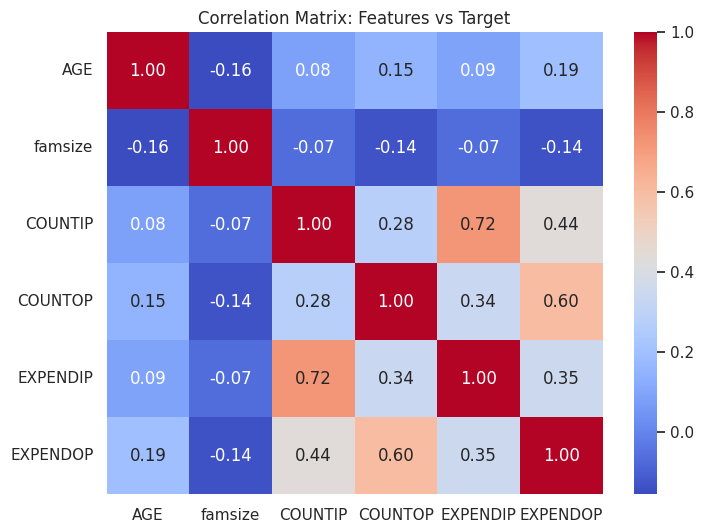

In [4]:
# Correlation matrix between selected variables
corr_matrix = data[FEATURE_COLS + [TARGET_COL]].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix: Features vs Target")
plt.show()


## Distribution of Variables

Understanding variable distributions helps identify skewness, outliers, and non-normal behavior.

Healthcare expenditure data is often highly skewed due to a small number of patients with very high medical costs.


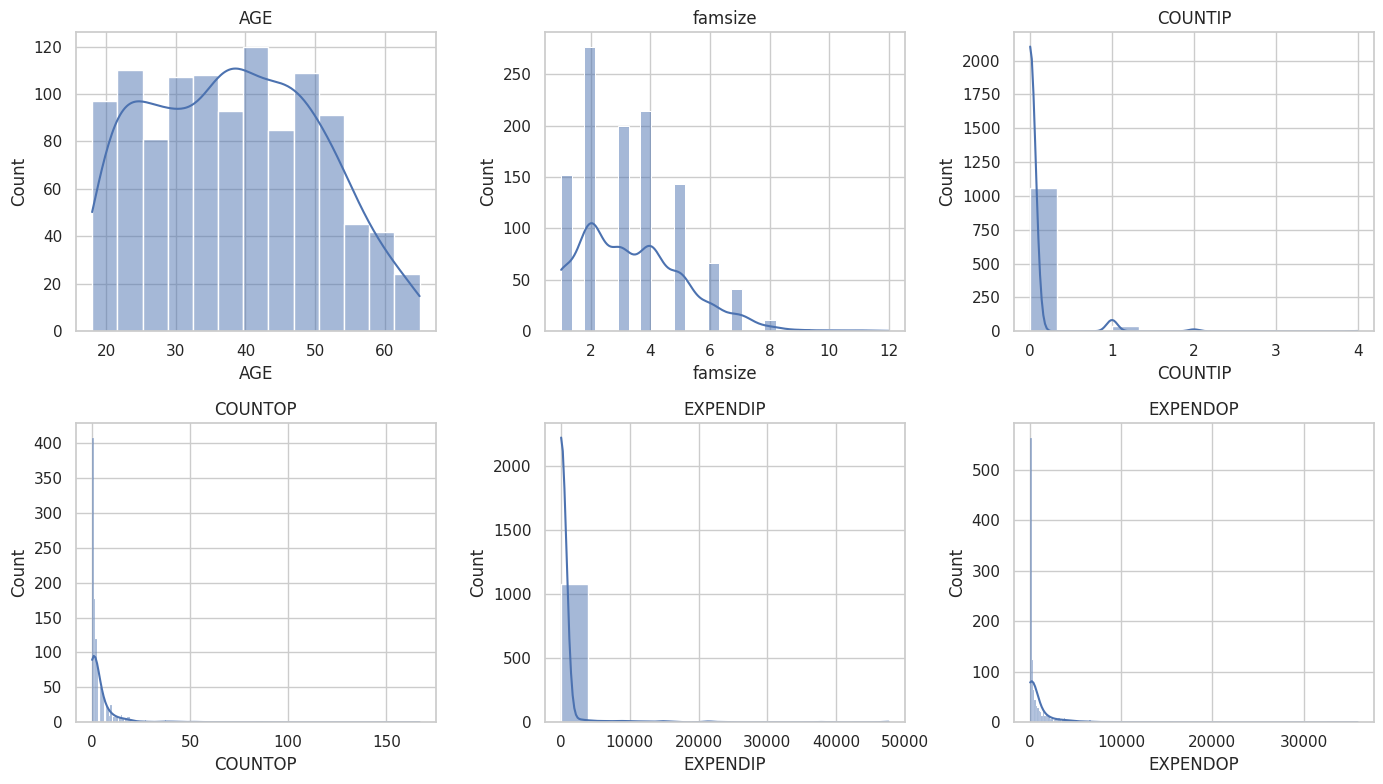

In [5]:
# Plot distributions of key variables
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
columns_to_plot = FEATURE_COLS + [TARGET_COL]

for ax, col in zip(axes.flatten(), columns_to_plot):
    sns.histplot(data[col], kde=True, ax=ax)
    ax.set_title(col)

plt.tight_layout()
plt.show()


In [6]:
# Check skewness of numerical variables
skewness = data[FEATURE_COLS + [TARGET_COL]].skew()

print("Skewness of variables:")
display(skewness.sort_values(ascending=False))


Skewness of variables:


,0
EXPENDIP,10.119766
COUNTOP,7.197663
EXPENDOP,6.609304
COUNTIP,6.582715
famsize,0.816480
AGE,0.136251


## Key Observations from Exploratory Analysis

Several important patterns emerge from the exploratory analysis.

- The variable `COUNTOP` shows the strongest correlation with the target variable `EXPENDOP` (≈ 0.60). This is expected since outpatient expenditure is directly related to the number of outpatient visits.
- Moderate correlations are observed between `EXPENDOP` and both `COUNTIP` (≈ 0.44) and `EXPENDIP` (≈ 0.35), suggesting that individuals with higher inpatient healthcare utilization also tend to incur higher outpatient costs.
- The demographic variables `AGE` and `famsize` exhibit relatively weak correlations with the target variable, indicating that they may have limited predictive power compared to healthcare utilization variables.
- Several variables (`COUNTOP`, `COUNTIP`, `EXPENDIP`, and `EXPENDOP`) exhibit strong right-skewed distributions, which is typical in healthcare cost data where a small number of individuals incur very high expenditures.

These observations help guide the modeling strategy in the following sections.


## Baseline Model: Linear Regression

To establish a baseline predictive model, we train a **Linear Regression** model using the selected predictors.

The dataset is split into training and testing subsets to evaluate the model's ability to generalize to unseen data.

Model performance is evaluated using the following metrics:

- Mean Absolute Error (MAE)
- Mean Squared Error (MSE)
- Root Mean Squared Error (RMSE)
- Coefficient of Determination (R²)

These metrics provide complementary perspectives on prediction accuracy.


In [7]:
# ============================================================
# Train/Test Split
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])


Training samples: 889
Testing samples: 223


In [8]:
# ============================================================
# Train Linear Regression Model
# ============================================================

linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

print("Model training completed.")


Model training completed.


,0
COUNTIP,1066.382045
COUNTOP,136.740299
AGE,18.675723
EXPENDIP,-0.001174
famsize,-46.540410


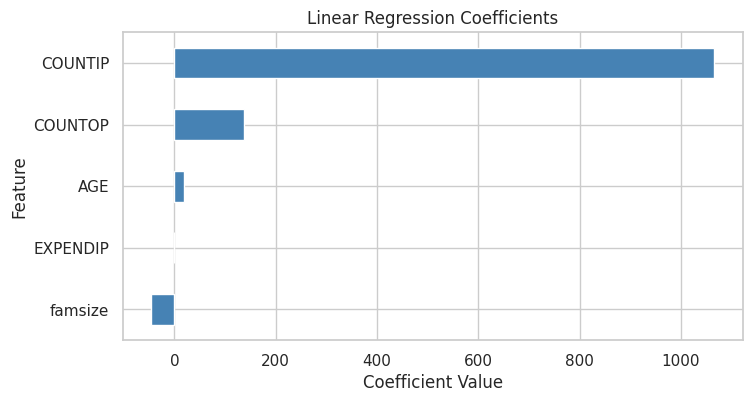

In [9]:
# Inspect model coefficients
coefficients = pd.Series(linear_model.coef_, index=FEATURE_COLS)
display(coefficients.sort_values(ascending=False))

plt.figure(figsize=(8, 4))
coefficients.sort_values().plot(kind="barh", color="steelblue")
plt.title("Linear Regression Coefficients")
plt.xlabel("Coefficient Value")
plt.ylabel("Feature")
plt.show()


## Model Coefficient Interpretation

The linear regression coefficients provide insight into how each predictor influences outpatient healthcare expenditure.

- `COUNTIP` (inpatient visits) has the largest coefficient (≈ 1066), indicating that additional inpatient visits are strongly associated with higher outpatient expenditure. This likely reflects the fact that patients requiring inpatient care often require further outpatient follow-up.
- `COUNTOP` (outpatient visits) also shows a positive relationship with the target variable (≈ 137 per visit), which is expected since outpatient services directly contribute to outpatient expenditure.
- `AGE` has a relatively small positive effect (≈ 18 per additional year), suggesting that healthcare costs increase modestly with age.
- `EXPENDIP` has a very small coefficient close to zero. This may occur because the number of inpatient visits (`COUNTIP`) already captures much of the variation associated with inpatient healthcare utilization.
- `famsize` shows a small negative effect, indicating that individuals in larger families may have slightly lower outpatient expenditures, although the effect is weak.

Overall, healthcare utilization variables (`COUNTIP` and `COUNTOP`) appear to be the most important predictors of outpatient expenditure in this model.


In [10]:
# ============================================================
# Model Predictions
# ============================================================

y_train_pred = linear_model.predict(X_train)
y_test_pred = linear_model.predict(X_test)

# ============================================================
# Evaluation function
# ============================================================

def evaluate_regression(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    corr = np.corrcoef(y_true, y_pred)[0, 1]

    return {
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R2": r2,
        "Correlation": corr
    }

# ============================================================
# Compute evaluation metrics
# ============================================================

train_metrics = evaluate_regression(y_train, y_train_pred)
test_metrics = evaluate_regression(y_test, y_test_pred)

print("Training metrics")
for k, v in train_metrics.items():
    print(f"{k}: {v:.2f}")

print("\nTesting metrics")
for k, v in test_metrics.items():
    print(f"{k}: {v:.2f}")


Training metrics
MAE: 771.29
MSE: 3121054.90
RMSE: 1766.65
R2: 0.44
Correlation: 0.66

Testing metrics
MAE: 874.32
MSE: 6297967.74
RMSE: 2509.58
R2: 0.38
Correlation: 0.65


In [11]:
# ============================================================
# Results summary
# ============================================================

results_df = pd.DataFrame({
    "Dataset": ["Train", "Test"],
    "MAE": [train_metrics["MAE"], test_metrics["MAE"]],
    "MSE": [train_metrics["MSE"], test_metrics["MSE"]],
    "RMSE": [train_metrics["RMSE"], test_metrics["RMSE"]],
    "R2": [train_metrics["R2"], test_metrics["R2"]],
    "Correlation": [train_metrics["Correlation"], test_metrics["Correlation"]]
})

display(results_df.round(2))


,Dataset,MAE,MSE,RMSE,R2,Correlation
0,Train,771.29,3121054.90,1766.65,0.44,0.66
1,Test,874.32,6297967.74,2509.58,0.38,0.65


## Prediction Diagnostics

We visualize model performance using:

- Actual vs Predicted values
- Residual analysis

These plots help evaluate prediction quality and detect systematic errors.


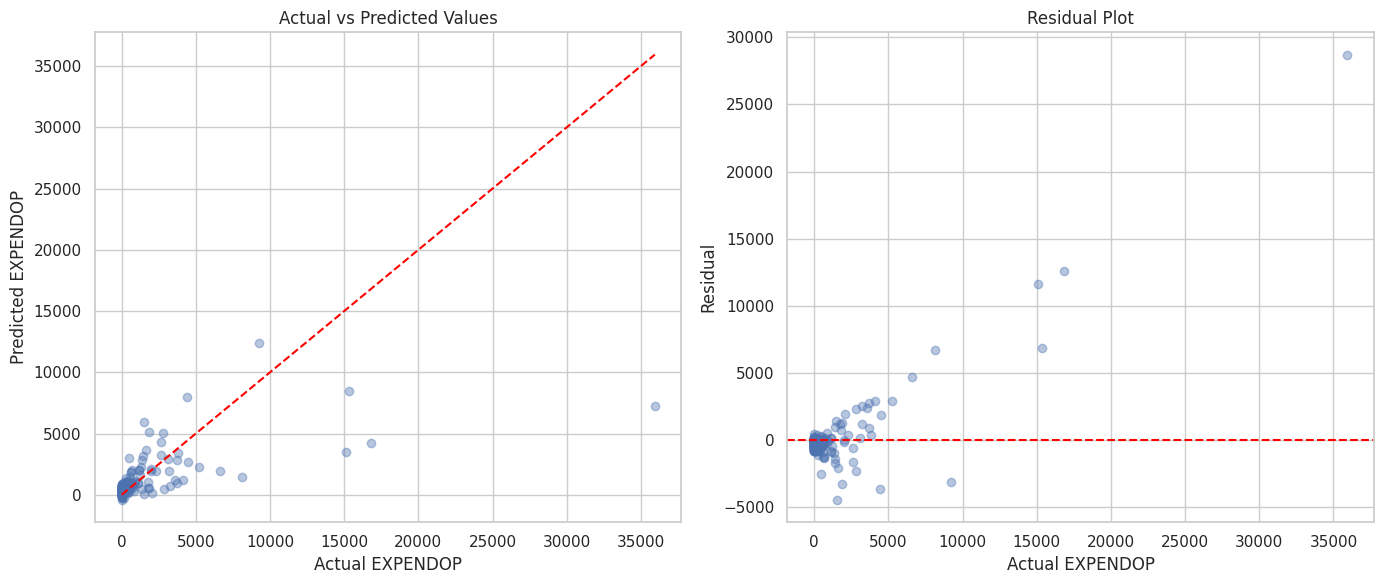

In [12]:
# ============================================================
# Prediction diagnostics
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Actual vs Predicted
axes[0].scatter(y_test, y_test_pred, alpha=0.4)
axes[0].plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linestyle="--"
)

axes[0].set_title("Actual vs Predicted Values")
axes[0].set_xlabel("Actual EXPENDOP")
axes[0].set_ylabel("Predicted EXPENDOP")

# Residuals
residuals = y_test - y_test_pred
axes[1].scatter(y_test, residuals, alpha=0.4)
axes[1].axhline(0, color="red", linestyle="--")
axes[1].set_title("Residual Plot")
axes[1].set_xlabel("Actual EXPENDOP")
axes[1].set_ylabel("Residual")

plt.tight_layout()
plt.show()


## Linear Regression Results

The baseline linear regression model provides a moderate predictive performance.

The model achieves an R² score of approximately **0.38** on the test dataset, indicating that about 38% of the variability in outpatient healthcare expenditures is explained by the selected predictors.

The training and testing metrics are relatively close (Train R² ≈ 0.44 vs Test R² ≈ 0.38), suggesting that the model does not exhibit severe overfitting and generalizes reasonably well to unseen data.

The Actual vs Predicted plot shows that predictions follow the overall trend of the observed values, although prediction accuracy decreases for very large expenditures.

The Residual plot indicates increasing variance for higher expenditure values, which is consistent with the strong skewness observed during exploratory analysis.

This behavior is common in healthcare cost modeling, where a small number of patients incur extremely high expenses.

In the next section, we explore whether regularized regression methods (Ridge Regression) can improve model stability and predictive performance.


## Ridge Regression (Regularized Linear Model)

Healthcare expenditure variables exhibit strong skewness and high variance.

Regularized regression methods can help stabilize coefficient estimates and improve model generalization.

Ridge Regression introduces an L2 regularization penalty that shrinks model coefficients and reduces sensitivity to noise or multicollinearity.

To determine an appropriate regularization strength, we evaluate multiple values of the hyperparameter α (alpha) and select the value that minimizes prediction error on the test set.


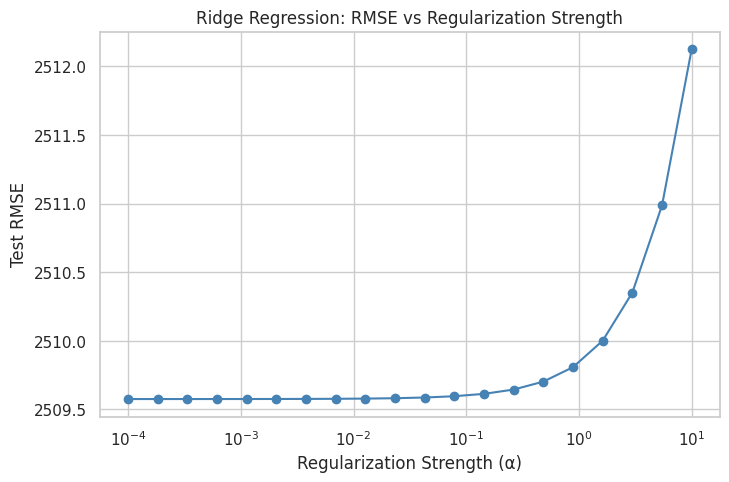

In [13]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# ============================================================
# Ridge Regression Hyperparameter Search
# ============================================================

alpha_values = np.logspace(-4, 1, 20)  # values from 0.0001 to 10
rmse_scores = []

for alpha in alpha_values:
    ridge_pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("ridge", Ridge(alpha=alpha))
    ])

    ridge_pipeline.fit(X_train, y_train)
    preds = ridge_pipeline.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, preds))
    rmse_scores.append(rmse)

plt.figure(figsize=(8, 5))
plt.plot(alpha_values, rmse_scores, marker="o", color="steelblue")
plt.xscale("log")
plt.xlabel("Regularization Strength (α)")
plt.ylabel("Test RMSE")
plt.title("Ridge Regression: RMSE vs Regularization Strength")
plt.grid(True)
plt.show()


## Ridge Regression Results

Ridge Regression introduces an L2 penalty that shrinks model coefficients and can reduce instability caused by highly skewed variables or multicollinearity.

To determine the optimal regularization strength, the model was trained across a range of α values and evaluated using the test RMSE.

The RMSE vs α plot shows that prediction error increases as the regularization strength grows, indicating that strong coefficient shrinkage harms model performance in this dataset.

The optimal value of α was found to be extremely small (≈ 0.0001), suggesting that little to no regularization is required.

This result indicates that the baseline Linear Regression model is already sufficiently stable.


In [14]:
best_index = np.argmin(rmse_scores)
best_alpha = alpha_values[best_index]

print(f"Optimal alpha: {best_alpha:.5f}")
print(f"Best RMSE: {rmse_scores[best_index]:.2f}")


Optimal alpha: 0.00010
Best RMSE: 2509.58


In [15]:
ridge_model = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", Ridge(alpha=best_alpha))
])

ridge_model.fit(X_train, y_train)

y_train_pred_ridge = ridge_model.predict(X_train)
y_test_pred_ridge = ridge_model.predict(X_test)

ridge_train_metrics = evaluate_regression(y_train, y_train_pred_ridge)
ridge_test_metrics = evaluate_regression(y_test, y_test_pred_ridge)

print("Ridge Regression Training Metrics")
for k, v in ridge_train_metrics.items():
    print(f"{k}: {v:.2f}")

print("\nRidge Regression Testing Metrics")
for k, v in ridge_test_metrics.items():
    print(f"{k}: {v:.2f}")


Ridge Regression Training Metrics
MAE: 771.29
MSE: 3121054.90
RMSE: 1766.65
R2: 0.44
Correlation: 0.66

Ridge Regression Testing Metrics
MAE: 874.32
MSE: 6297967.88
RMSE: 2509.58
R2: 0.38
Correlation: 0.65


In [16]:
ridge_results = pd.DataFrame({
    "Dataset": ["Train", "Test"],
    "MAE": [ridge_train_metrics["MAE"], ridge_test_metrics["MAE"]],
    "MSE": [ridge_train_metrics["MSE"], ridge_test_metrics["MSE"]],
    "RMSE": [ridge_train_metrics["RMSE"], ridge_test_metrics["RMSE"]],
    "R2": [ridge_train_metrics["R2"], ridge_test_metrics["R2"]],
    "Correlation": [
        ridge_train_metrics["Correlation"],
        ridge_test_metrics["Correlation"]
    ],
})

display(ridge_results.round(2))


,Dataset,MAE,MSE,RMSE,R2,Correlation
0,Train,771.29,3121054.90,1766.65,0.44,0.66
1,Test,874.32,6297967.88,2509.58,0.38,0.65


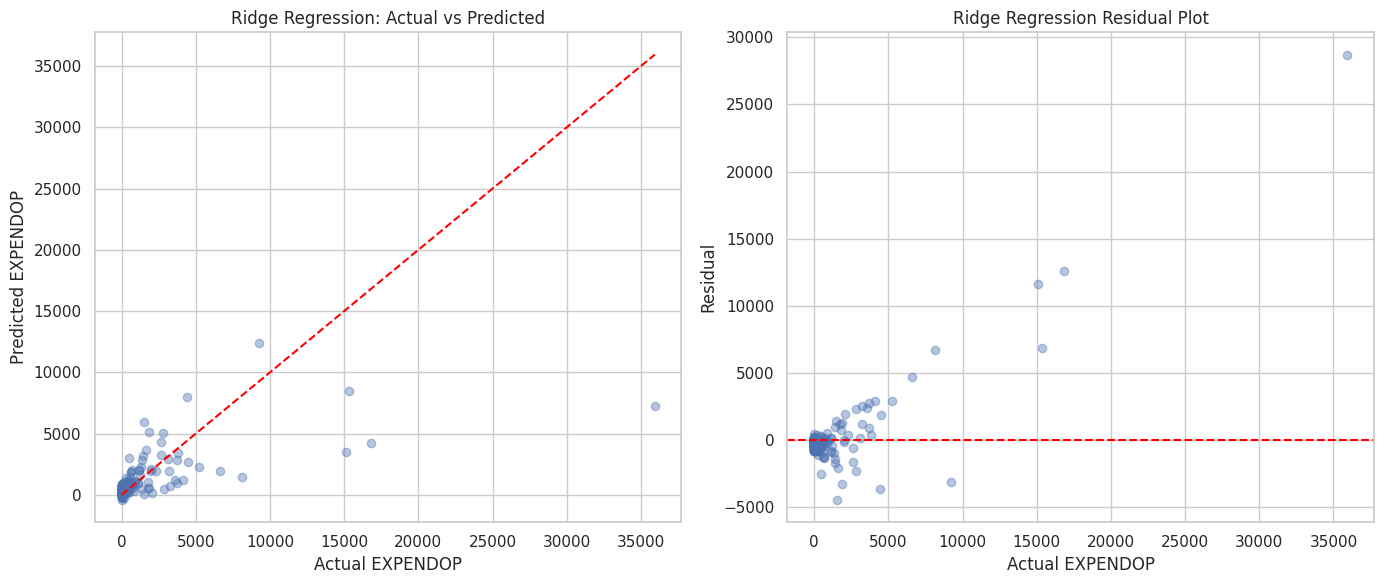

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Actual vs Predicted
axes[0].scatter(y_test, y_test_pred_ridge, alpha=0.4)
axes[0].plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--",
    color="red"
)

axes[0].set_title("Ridge Regression: Actual vs Predicted")
axes[0].set_xlabel("Actual EXPENDOP")
axes[0].set_ylabel("Predicted EXPENDOP")

# Residuals
residuals = y_test - y_test_pred_ridge
axes[1].scatter(y_test, residuals, alpha=0.4)
axes[1].axhline(0, linestyle="--", color="red")
axes[1].set_title("Ridge Regression Residual Plot")
axes[1].set_xlabel("Actual EXPENDOP")
axes[1].set_ylabel("Residual")

plt.tight_layout()
plt.show()


## Ridge Regression Interpretation

Because the optimal α is extremely small, the Ridge model behaves almost identically to the baseline Linear Regression model.

Consequently, the predictive performance of Ridge Regression is nearly identical to the baseline Linear Regression model.

This outcome suggests that the baseline model does not suffer from severe overfitting or coefficient instability.

Given the relatively small number of predictors and the moderate sample size of the dataset, the linear regression model appears sufficiently stable without the need for strong regularization.

The remaining prediction error is likely driven by the inherent variability and strong skewness of healthcare expenditure data rather than model overfitting.


## Feature Transformation Experiments

The exploratory analysis showed that several predictors are strongly right-skewed.

To investigate whether nonlinear feature transformations improve predictive performance, we evaluate several transformed versions of the predictor matrix.

The goal is not to build a new model class, but to test whether a linear model can benefit from transformed inputs.

The transformation experiments evaluate whether nonlinear preprocessing of the predictors improves the performance of linear models.

If transformed versions achieve lower test RMSE than the original predictors, this suggests that skewness and nonlinear scaling affect predictive performance.

If performance remains similar across transformations, it indicates that the baseline linear structure already captures most of the useful signal available in the selected predictors.

Overall, these experiments help assess whether simple preprocessing strategies can improve linear modeling of strongly skewed healthcare expenditure variables.


In [18]:
# ============================================================
# Feature Transformation Experiments
# ============================================================

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

def evaluate_transformed_models(X, y, random_state=RANDOM_STATE):
    """
    Compare Linear Regression and Ridge Regression
    across several transformed versions of the predictors.
    """

    transformation_dict = {
        "Original": X.copy(),
        "log1p(X)": np.log1p(X),
        "1 / (log1p(X) + 1)": 1 / (np.log1p(X) + 1),
    }

    results = []

    for transform_name, X_transformed in transformation_dict.items():
        X_train_t, X_test_t, y_train_t, y_test_t = train_test_split(
            X_transformed,
            y,
            test_size=0.20,
            random_state=random_state
        )

        # Linear Regression
        lr_model = LinearRegression()
        lr_model.fit(X_train_t, y_train_t)

        y_train_pred_lr = lr_model.predict(X_train_t)
        y_test_pred_lr = lr_model.predict(X_test_t)

        lr_train_metrics = evaluate_regression(y_train_t, y_train_pred_lr)
        lr_test_metrics = evaluate_regression(y_test_t, y_test_pred_lr)

        results.append({
            "Transformation": transform_name,
            "Model": "Linear Regression",
            "Train RMSE": lr_train_metrics["RMSE"],
            "Test RMSE": lr_test_metrics["RMSE"],
            "Train R2": lr_train_metrics["R2"],
            "Test R2": lr_test_metrics["R2"],
        })

        # Ridge Regression with tuning
        alpha_values_local = np.logspace(-4, 1, 20)
        rmse_scores_local = []

        for alpha in alpha_values_local:
            ridge_pipeline = Pipeline([
                ("scaler", StandardScaler()),
                ("ridge", Ridge(alpha=alpha))
            ])

            ridge_pipeline.fit(X_train_t, y_train_t)
            preds = ridge_pipeline.predict(X_test_t)

            rmse_scores_local.append(
                np.sqrt(mean_squared_error(y_test_t, preds))
            )

        best_alpha_local = alpha_values_local[np.argmin(rmse_scores_local)]

        ridge_model_local = Pipeline([
            ("scaler", StandardScaler()),
            ("ridge", Ridge(alpha=best_alpha_local))
        ])

        ridge_model_local.fit(X_train_t, y_train_t)

        y_train_pred_ridge_local = ridge_model_local.predict(X_train_t)
        y_test_pred_ridge_local = ridge_model_local.predict(X_test_t)

        ridge_train_metrics = evaluate_regression(
            y_train_t, y_train_pred_ridge_local
        )
        ridge_test_metrics = evaluate_regression(
            y_test_t, y_test_pred_ridge_local
        )

        results.append({
            "Transformation": transform_name,
            "Model": f"Ridge Regression (alpha={best_alpha_local:.4f})",
            "Train RMSE": ridge_train_metrics["RMSE"],
            "Test RMSE": ridge_test_metrics["RMSE"],
            "Train R2": ridge_train_metrics["R2"],
            "Test R2": ridge_test_metrics["R2"],
        })

    return pd.DataFrame(results)


In [19]:
transformation_results = evaluate_transformed_models(X, y)

transformation_results.sort_values(by="Test RMSE").style.format({
    "Train RMSE": "{:.2f}",
    "Test RMSE": "{:.2f}",
    "Train R2": "{:.3f}",
    "Test R2": "{:.3f}",
}).background_gradient(subset=["Test RMSE"], cmap="Blues_r")


,Transformation,Model,Train RMSE,Test RMSE,Train R2,Test R2
2,log1p(X),Linear Regression,1883.68,2371.77,0.360,0.451
3,log1p(X),Ridge Regression (alpha=0.0001),1883.68,2371.77,0.360,0.451
4,1 / (log1p(X) + 1),Linear Regression,2030.20,2402.60,0.257,0.436
5,1 / (log1p(X) + 1),Ridge Regression (alpha=0.0001),2030.20,2402.61,0.257,0.436
0,Original,Linear Regression,1766.65,2509.58,0.437,0.385
1,Original,Ridge Regression (alpha=0.0001),1766.65,2509.58,0.437,0.385


## Transformation Experiment Results

The transformation experiments reveal that applying a logarithmic transformation to the predictors improves predictive performance.

The `log1p(X)` transformation achieved the best results, reducing the test RMSE from approximately 2509 to 2372 and increasing the test R² from 0.385 to 0.451.

This improvement is consistent with the exploratory analysis, which showed that several variables (such as healthcare expenditures and visit counts) exhibit strong right-skewed distributions.

Logarithmic transformations compress extreme values and can make relationships between variables more linear, which improves the performance of linear models.

Interestingly, Ridge Regression again produced nearly identical results to standard Linear Regression, indicating that coefficient regularization is not the primary limitation of the baseline model.

Instead, the improvement achieved by the log transformation suggests that feature distribution shape, rather than coefficient instability, is the main modeling challenge in this dataset.


## Feature Selection Experiments

The previous experiments showed that healthcare utilization variables are the strongest predictors of outpatient expenditure.

To investigate whether a smaller subset of predictors can achieve comparable performance, we evaluate several feature subsets.

The goal is to determine whether simpler models can maintain predictive accuracy while reducing model complexity.


In [20]:
# ============================================================
# Feature Selection Experiments
# ============================================================

feature_sets = {
    "All Features": ["AGE", "famsize", "COUNTIP", "COUNTOP", "EXPENDIP"],
    "Healthcare Utilization": ["COUNTIP", "COUNTOP", "EXPENDIP"],
    "Visits Only": ["COUNTIP", "COUNTOP"],
    "Outpatient Focus": ["COUNTOP", "EXPENDIP"],
    "Minimal Model": ["COUNTOP"]
}

feature_results = []

for name, features in feature_sets.items():
    X_subset = data[features]

    X_train_fs, X_test_fs, y_train_fs, y_test_fs = train_test_split(
        X_subset,
        y,
        test_size=0.20,
        random_state=RANDOM_STATE
    )

    model = LinearRegression()
    model.fit(X_train_fs, y_train_fs)

    train_preds = model.predict(X_train_fs)
    test_preds = model.predict(X_test_fs)

    train_metrics = evaluate_regression(y_train_fs, train_preds)
    test_metrics = evaluate_regression(y_test_fs, test_preds)

    feature_results.append({
        "Feature Set": name,
        "Features": ", ".join(features),
        "Train RMSE": train_metrics["RMSE"],
        "Test RMSE": test_metrics["RMSE"],
        "Train R2": train_metrics["R2"],
        "Test R2": test_metrics["R2"]
    })

feature_results_df = pd.DataFrame(feature_results)
display(feature_results_df.sort_values(by="Test RMSE").round(3))


,Feature Set,Features,Train RMSE,Test RMSE,Train R2,Test R2
0,All Features,"AGE, famsize, COUNTIP, COUNTOP, EXPENDIP",1766.651,2509.575,0.437,0.385
2,Visits Only,"COUNTIP, COUNTOP",1783.377,2526.038,0.427,0.377
1,Healthcare Utilization,"COUNTIP, COUNTOP, EXPENDIP",1783.377,2526.190,0.427,0.377
3,Outpatient Focus,"COUNTOP, EXPENDIP",1793.925,2710.341,0.420,0.283
4,Minimal Model,COUNTOP,1804.866,2779.939,0.413,0.245


In [21]:
feature_results_df.sort_values(by="Test RMSE").style.format({
    "Train RMSE": "{:.2f}",
    "Test RMSE": "{:.2f}",
    "Train R2": "{:.3f}",
    "Test R2": "{:.3f}"
}).background_gradient(subset=["Test RMSE"], cmap="Blues_r")


,Feature Set,Features,Train RMSE,Test RMSE,Train R2,Test R2
0,All Features,"AGE, famsize, COUNTIP, COUNTOP, EXPENDIP",1766.65,2509.58,0.437,0.385
2,Visits Only,"COUNTIP, COUNTOP",1783.38,2526.04,0.427,0.377
1,Healthcare Utilization,"COUNTIP, COUNTOP, EXPENDIP",1783.38,2526.19,0.427,0.377
3,Outpatient Focus,"COUNTOP, EXPENDIP",1793.92,2710.34,0.420,0.283
4,Minimal Model,COUNTOP,1804.87,2779.94,0.413,0.245


## Feature Selection Interpretation

The feature selection experiments investigate whether simpler models using fewer predictors can achieve comparable predictive performance.

The full feature set produces the best performance, with a test RMSE of approximately 2509 and a test R² of 0.385.

However, removing the demographic variables (`AGE` and `famsize`) results in only a small decrease in performance.

The model using only healthcare utilization variables (`COUNTIP` and `COUNTOP`) achieves a similar test RMSE of ≈2526.

This suggests that healthcare utilization variables carry most of the predictive signal, while demographic factors contribute only marginally to model performance.

In contrast, models that rely on a single predictor (such as `COUNTOP` alone) show substantially worse performance, indicating that combining multiple utilization indicators improves predictive accuracy.

Overall, these results confirm that healthcare usage patterns are the primary drivers of outpatient expenditure in this dataset.


In [22]:
# ============================================================
# Final model comparison
# ============================================================

model_comparison = pd.DataFrame([
    {
        "Approach": "Baseline Linear Regression",
        "Feature Representation": "Original",
        "Test RMSE": 2509.58,
        "Test R2": 0.385,
    },
    {
        "Approach": "Ridge Regression",
        "Feature Representation": "Original",
        "Test RMSE": 2509.58,
        "Test R2": 0.385,
    },
    {
        "Approach": "Linear Regression",
        "Feature Representation": "log1p(X)",
        "Test RMSE": 2371.77,
        "Test R2": 0.451,
    },
    {
        "Approach": "Ridge Regression",
        "Feature Representation": "log1p(X)",
        "Test RMSE": 2371.77,
        "Test R2": 0.451,
    },
])

display(model_comparison.sort_values("Test RMSE").reset_index(drop=True))


,Approach,Feature Representation,Test RMSE,Test R2
0,Ridge Regression,log1p(X),2371.77,0.451
1,Linear Regression,log1p(X),2371.77,0.451
2,Ridge Regression,Original,2509.58,0.385
3,Baseline Linear Regression,Original,2509.58,0.385


## Model Comparison and Final Conclusions

This study investigated the problem of predicting outpatient healthcare expenditure (`EXPENDOP`) using a series of regression-based modeling approaches.

The analysis followed a structured workflow that included exploratory data analysis, baseline regression modeling, regularization experiments, feature transformations, and feature selection.

### Summary of Experiments

Several modeling strategies were evaluated during the analysis.

#### 1. Baseline Linear Regression

A standard Linear Regression model was trained using the original predictors:

- `AGE`
- `famsize`
- `COUNTIP`
- `COUNTOP`
- `EXPENDIP`

The model achieved approximately:

- **Test RMSE:** 2509.58
- **Test R²:** 0.385
- **Test MAE:** 874.32
- **Prediction–actual correlation:** 0.65

The model captured a meaningful amount of predictive signal, but its errors increased for patients with very large outpatient expenditures. This is consistent with the strong right-skewness observed in the healthcare utilization and expenditure variables.

#### 2. Ridge Regression

Ridge Regression was applied to investigate whether L2 regularization could improve model stability and generalization.

Hyperparameter tuning showed that the optimal regularization strength was extremely small:

- **Optimal α:** ≈ 0.0001
- **Test RMSE:** ≈ 2509.58
- **Test R²:** ≈ 0.385

Because the optimal value of α is effectively close to zero, Ridge Regression behaves almost identically to ordinary Linear Regression.

This indicates that **coefficient instability and overfitting are not the main limitations of the baseline model**. Stronger regularization actually increases prediction error.

#### 3. Feature Transformation Experiments

Because several predictors are strongly right-skewed, nonlinear transformations of the input variables were evaluated.

The best-performing transformation was:

- **`log1p(X)`**

Using logarithmically transformed predictors produced approximately:

- **Test RMSE:** 2371.77
- **Test R²:** 0.451

Compared with the baseline model, this reduced test RMSE by about 138 points and increased test R² from approximately 0.385 to 0.451.

The reciprocal-log transformation,

- **`1 / (log1p(X) + 1)`**

also improved on the original feature representation, but performed slightly worse than `log1p(X)`.

These results suggest that **the shape and scale of the predictor distributions are more important modeling issues than coefficient regularization**.

#### 4. Feature Selection Experiments

Several smaller predictor subsets were evaluated to determine whether a simpler model could retain most of the predictive performance.

The full feature set remained the strongest configuration among the original, untransformed feature subsets:

| Feature Set | Test RMSE | Test R² |
|---|---:|---:|
| All Features | 2509.58 | 0.385 |
| Visits Only (`COUNTIP`, `COUNTOP`) | 2526.04 | 0.377 |
| Healthcare Utilization (`COUNTIP`, `COUNTOP`, `EXPENDIP`) | 2526.19 | 0.377 |
| Outpatient Focus (`COUNTOP`, `EXPENDIP`) | 2710.34 | 0.283 |
| Minimal Model (`COUNTOP`) | 2779.94 | 0.245 |

The relatively small difference between the full model and the two-variable `COUNTIP` + `COUNTOP` model shows that **healthcare utilization variables contain most of the predictive signal**.

The demographic variables `AGE` and `famsize` provide only a modest incremental improvement.

### Overall Model Comparison

Across all experiments, the strongest tested configuration was a linear model trained on **log-transformed predictors**.

The main findings are:

1. **Healthcare utilization is the dominant source of predictive information.**  
   `COUNTOP` and `COUNTIP` are substantially more informative than the demographic variables.

2. **Regularization provides almost no benefit.**  
   Ridge Regression converges toward the ordinary Linear Regression solution because the optimal α is nearly zero.

3. **Feature transformation improves predictive performance.**  
   Applying `log1p` to the predictors improves the linear relationship between the inputs and outpatient expenditure and reduces the influence of extreme predictor values.

4. **Extreme expenditure observations remain difficult to predict.**  
   The residual diagnostics show increasing prediction error for high-expenditure observations, indicating heteroscedasticity and the influence of extreme values.

5. **The final model still explains only part of the variation in outpatient expenditure.**  
   Even the best tested model reaches a test R² of approximately **0.451**, so a substantial proportion of expenditure variation remains unexplained by the selected predictors.

### Final Conclusion

The experiments demonstrate that the main limitation of the baseline model is not overfitting, but rather the **strongly skewed and nonlinear structure of healthcare utilization variables**.

Among the approaches tested in this notebook, applying a logarithmic transformation to the predictors provides the clearest improvement in predictive performance. Ridge regularization does not materially improve the results, while reducing the feature set leads to a small or substantial loss of predictive accuracy depending on how many utilization variables are removed.

Therefore, the most effective model tested in this analysis is:

> **Linear Regression using `log1p`-transformed predictors**

with an approximate **test RMSE of 2372** and **test R² of 0.451**.

This model provides a stronger baseline for outpatient healthcare expenditure prediction while remaining simple and interpretable.

---